# PHY588 Problem Set 1

### David Koranteng

## Problem 1

A) I will be fitting a model to determine the rest-frame relationship between the input stretch parameter ($x_1$) to the SALT2 Type Ia Supernova model and the resulting decline time ($\Delta m_{15}$) of the supernova light curve. I will be using the least-squares method to determine my likelihood since the data do not have error bars. Because of this, the data is assumed to be inherently Gaussian. Having previously plotted the data, the relationship between $x_1$ and $\Delta m_{15}$ appears to be linear. That said, in the paper in which SALT2 is initially defined (Guy et al. 2007), $\Delta m_{15}$ is related to $x_1$ via a third degree polynomial. I will start with a linear model, and test higher order polynomials using model selection.



In [223]:
import numpy as np
import sncosmo
import pandas as pd
import redback
from redback.simulate_transients import SimulateGenericTransient
import matplotlib.pyplot as plt
from astropy.cosmology import LambdaCDM
from scipy.interpolate import interp1d
from bilby.core.prior import Uniform
from scipy.optimize import least_squares
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.special import gamma, factorial, gammaln, gammasgn


import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

In [242]:
## Lists for the stretch and decline rate parameters. 
list_delta_m15 = []
list_x1 = []

## Producing 1000 SALT2 lightcurves with a range of x1 values and determining their decline rates
for i in range(1000):
    params = redback.priors.get_priors(model='salt2').sample()
    params['redshift'] = 0      ## To find the rest frame relationship

    times = np.linspace(0.2,80,100)   ## Days for the light curve
    bands = ['lsstg']
    model_kwargs = {'bands':bands, 'output_format':'magnitude'}


    ## Simulating the LCs
    sn_obs = SimulateGenericTransient(model='salt2', parameters=params,
                                    times=times, data_points=100, model_kwargs=model_kwargs,
                                    multiwavelength_transient=True, noise_term=0.0)

    ## Using Nearest Neighbours interpolation to approximate the decline rate
    mag_interp = interp1d(x=sn_obs.data['time'], y=sn_obs.data['output'], kind='nearest')
    time_interp = interp1d(x=sn_obs.data['output'], y=sn_obs.data['time'])

    peak_mag = mag_interp(params['peak_time'])
    decline_mag = mag_interp(params['peak_time'] + 15)

    delta_m15 = decline_mag - peak_mag

    list_delta_m15.append(delta_m15)
    list_x1.append(params['x1'])


B) I will optimize my model using the least squares minimization, scipy.optimize.least_squares. I will optimize my fit and plot the fit of the linear model to the data.

Slope, A = -0.11859303963930984 
Intercept, B = 0.8131215111325217


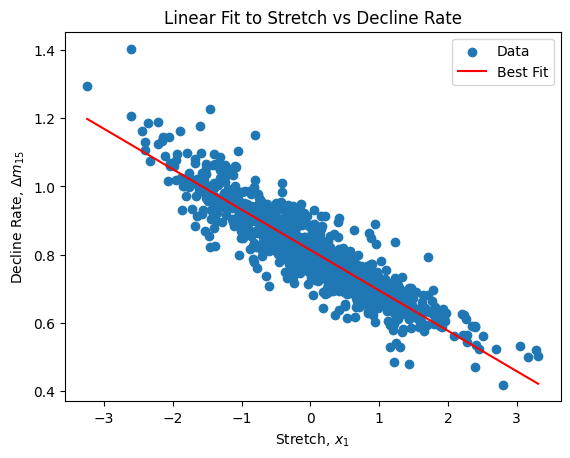

In [243]:
def linear_model(params, x):          ## Defining the linear model
    A, B = params
    return A*x + B

def residuals(params, x, y):        ## The residuals between the model and the data
    return y - linear_model(params, x)

## Converting lists to arrays
x_array = np.array(list_x1)
y_array = np.array(list_delta_m15)

## Initial values for the least squares function
x0 = [0, 0]

opt_params = least_squares(residuals, x0, args=(x_array, y_array)).x        # Output the optimized parameters from the linear model, Slope and Intercept

print(f'Slope, A = {opt_params[0]} \nIntercept, B = {opt_params[1]}')

x_test = np.linspace(min(x_array), max(x_array), 100)

plt.scatter(x_array, y_array, label='Data')
plt.plot(x_test, linear_model(opt_params, x_test), c='red', label='Best Fit')
plt.xlabel(r'Stretch, $x_1$')
plt.ylabel(r'Decline Rate, $\Delta m_{15}$')
plt.title('Linear Fit to Stretch vs Decline Rate')
plt.legend()
plt.show()


C) Model selection will be done using Bayesian Information Criteria (BIC) to ensure that the data is not overfit by having too many parameters. This will also show whether or not the linear fit is sufficient, or if the third order polynomial is an improvement. 

For BIC, we saw in class that
$$
BIC = -2ln[L_{max}] + KlnN
$$

From the textbook, the log likelihood for Gaussian data is 
$$

logL = -\sum{[\frac{(y_i - f(x_i))^2}{2\sigma_i^2}]} + C

$$

where
$$
C = - \frac{-N}{2}ln(2\pi \sigma^2)
$$

Thus,

$$
-2ln(L_{max}) = \frac{RSS}{\sigma^2} + Nln(2\pi \sigma^2)
$$

where RSS is the resdiual sum of squares. Since the data does not have error bars, $\sigma^2$ is not known. Optimizing the likelihood function with respect to $\sigma^2$ yields the following estimate for $\sigma^2$:

$$
\sigma^2 = RSS/N
$$

and after substituting this into -2ln(L):

$$
-2ln(L) = Nln(\frac{RSS}{N}) + constants
$$

Thus

$$
BIC = Nln(RSS/N) + Kln(N)
$$

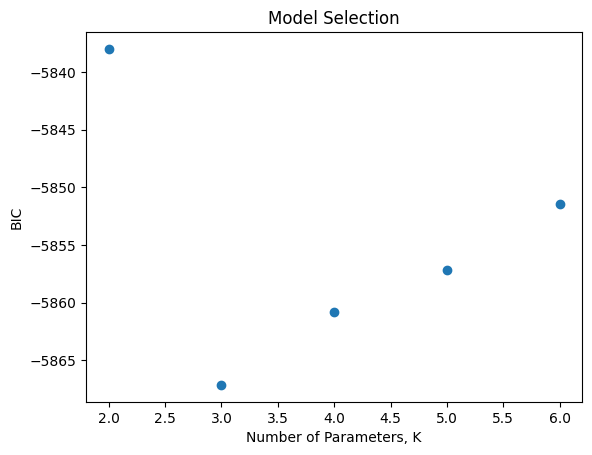

In [245]:
def BIC(RSS, N, K):         ## Definition of BIC
    return (N)*np.log(RSS/N) + K*np.log(N)

## Using Numpy's polyval to increase the degree of the polynomial when trying more complex models
def polynomial_model(params, x):
    return np.polyval(params, x)

## Residuals used for model selection
def poly_residuals(params, x, y):
    return y - polynomial_model(params, x)


## Trying everything from a linear fit to a 5th order polynomial
degrees = [1, 2, 3, 4, 5]
BICs = []
Ks = []

for degree in degrees:
    x0_poly = np.zeros(degree+1)
    poly_opt_params = least_squares(poly_residuals, x0_poly, args=(x_array, y_array)).x     ## Optimized Parameters
    RSS_poly = np.sum(least_squares(poly_residuals, x0_poly, args=(x_array, y_array)).fun**2)   ## Computes the residual sum of squares for BIC

    k = degree + 1  ## Number of parameters

    bic = BIC(RSS_poly, 1000, k)
    Ks.append(k)
    BICs.append(bic)


plt.scatter(Ks, BICs)
plt.xlabel('Number of Parameters, K')
plt.ylabel('BIC')
plt.title('Model Selection')
plt.show()


Based on the above plot, the ideal model (with minimized BIC) is the 3 parameter (second order) polynomial model, which is between my intial linear model and the third-order polynomial from the Guy et al. 2007 paper.

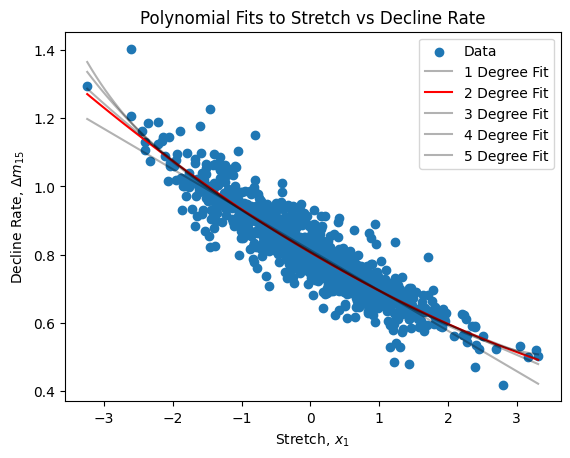

In [267]:
## Plotting all the fitted models, with the best fit model in red

plt.scatter(x_array, y_array, label='Data')
for degree in degrees:
    if degree == 2:
        col = 'red'
        alph = 1
    else:
        col = 'black'
        alph = 0.3
    x0_poly = np.zeros(degree+1)
    poly_opt_params = least_squares(poly_residuals, x0_poly, args=(x_array, y_array)).x     ## Optimized Parameters
    plt.plot(x_test, polynomial_model(poly_opt_params, x_test), c=col, label=f'{degree} Degree Fit', alpha=alph)



plt.xlabel(r'Stretch, $x_1$')
plt.ylabel(r'Decline Rate, $\Delta m_{15}$')
plt.title('Polynomial Fits to Stretch vs Decline Rate')
plt.legend()
plt.show()

## Problem 2

In class, we were given the following information to solve the murder mystery. 

The victim's M&Ms pack had the colour distribution, $\vec{x} = [9,9,8,6,7,5]$, for a total of $n_x = 44$. After buying 10 packs from each factory, we found that the packs had the following colour distributions: $\vec{c_A} = [115, 115, 54, 52, 55, 55]$ and $\vec{c_B} = [95, 98, 87, 57, 57, 57, 55]$. For $\vec{x}$, $\vec{c_A}$, and $\vec{c_B}$, the counts are ordered by their colours in the following way: [Blue, Orange, Green, Yellow, Red, Brown]. 

We seek to infer the probability that the victim's pack came from Factory A. This probability is represented by $\theta$. Therefore, we seek the following posterior:
$$
P(\theta | \vec{x}, \vec{c_A}, \vec{c_B})
$$

However, due to the presence of latent and nuissance parameters, $F\epsilon[A,B], \vec{\lambda_A}, \vec{\lambda_B}$, where $\vec{\lambda}$ represents the intrinsic colour fractions at factories A and B. Thus, the posterior we can infer through Baye's Rule is as follows:
$$
P(\theta, F, \vec{\lambda_A}, \vec{\lambda_B} | \vec{x}, \vec{c_A}, \vec{c_B}) \propto P(\theta)P(F|\theta)P(\vec{\lambda_A})P(\vec{\lambda_B})P(\vec{c_A} | \vec{\lambda_A})P(\vec{c_B} | \vec{\lambda_B})P(\vec{x} | F, \vec{\lambda_A}, \vec{\lambda_B})
$$

Since the instrinsic colour fractions at each factory are unknown, we must marginalize over these nuissance parameters by integrating over them, resulting in the posterior we intially wanted:
$$
P(\theta | \vec{x}, \vec{c_A}, \vec{c_B}) \propto \sum_{F\epsilon[A,B]}\int\int P(\theta, F, \vec{\lambda_A}, \vec{\lambda_B} | \vec{x}, \vec{c_A}, \vec{c_B}) d\vec{\lambda_A}d\vec{\lambda_B}
$$

Factoring out the prior for $\theta$ and expanding the summation yields the following:
$$
P(\theta | \vec{x}, \vec{c_A}, \vec{c_B}) \propto P(\theta) [P(\vec{x} | F=A, \vec{c_A})P(F=A|\theta) + P(\vec{x}|F=B, \vec{c_B})P(F=B | \theta)]
$$
Additionally,
$$
P(F=A|\theta) = \theta
$$

and 

$$
P(F=B | \theta) = (1-\theta)
$$

by definition. Combining this with the previously shown integrals yields the following:
$$
P(\theta | \vec{x}, \vec{c_A}, \vec{c_B}) \propto P(\theta) [\int P(\vec{x} | \vec{\lambda_A}) P(\vec{\lambda_A} | \vec{c_A}) d\vec{\lambda_A} + \int P(\vec{x} | \vec{\lambda_B}) P(\vec{\lambda_B} | \vec{c_B}) d\vec{\lambda_B}]
$$

As shown in class, each of these integrals can be solved using the Multinomial Dirichlet Predictive, reducing each integral to $L_A$ and $L_B$, respectively.

$$
L_A = \frac{n_x!}{\prod_{k} x_k!} \frac{\Gamma(\sum_k (\alpha_{0, k} + c_{A, k}))}{\Gamma(\sum_k (\alpha_{0, k} + c_{A, k} + n_x)} \prod_k \frac{\Gamma(\alpha_{0, k} + c_{A, k} + x_k)}{\Gamma(\alpha_{0, k} + c_{A, k})}
$$

Since the prior for $\theta$ is a Beta distribution, the posterior for it reduces to the following:
$$
P(\theta | \vec{x}, \vec{c_A}, \vec{c_B}) \propto [\theta L_A + (1-\theta)L_B]\theta^{\alpha-1}(1-\theta)^{\beta-1}
$$

This results in a sum of two beta functions:
$$
P(\theta | \vec{x}, \vec{c_A}, \vec{c_B}) \propto L_A\theta^{\alpha} (1-\theta)^{\beta - 1} + L_B\theta^{\alpha - 1}(1-\theta)^{\beta}
$$

Assuming flat priors, where $\alpha = \beta = 1$, this reduces to:
$$
P(\theta | \vec{x}, \vec{c_A}, \vec{c_B}) \propto L_A\theta + L_B(1-\theta)
$$

However, the quotient of Gamma functions in the middle of the above expression for $L_A$ and $L_B$ runs into floating point errors, since the Gamma function rises extremely quickly. As a result, the whole $L_A$ and $L_B$ values are returned as 0. I decided to take the natural log of $L_A$ and $L_B$ to avoid those errors, but this doesn't allow me to plot the log of the posterior. 

I discussed this problem with Alain and he suggested re-expressing the posterior as a function of the ratios of $L_A$ and $L_B$. I am not sure what the policy is regarding working together on Problem Sets. For clarification, all the above work on this question is my own, and all the below work is me attempting the process that Alain suggested. That said, none of this is copied from him. If collaboration is not allowed at all, disregard all work (on this question) beyond this point.

If $L_A = aL_B$, then the posterior can be expressed in the following way:

$$
P(\theta | \vec{x}, \vec{c_A}, \vec{c_B}) \propto aL_B\theta + L_B(1-\theta) = L_B(a\theta + (1-\theta))
$$

If I compute $a$, I can express the posterior as a non-normalized version of the above, by removing $L_B$. Since the above expression describes a proportionality rather than an equation, this is a valid approach. $a$ will be derived using the following logic:
$$
a = \frac{L_A}{L_B} = e^{ln(\frac{L_A}{L_B})} = e^{ln(L_A) - ln(L_B)}
$$

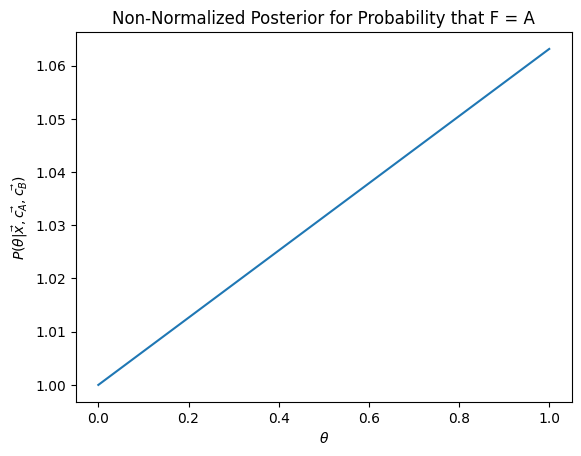

In [266]:
colors = ['blue', 'orange', 'green', 'yellow', 'red', 'brown']
x = [9,9,8,6,7,5]
c_A = [115,115,54,52,55,55]
c_B = [95,98,87,57,57,55]
alpha_0 = [1,1,1,1,1,1]

n_x = np.sum(x)
n_A = np.sum(c_A)
n_B = np.sum(c_B)



## Breaking the L_A and L_B functions into parts to avoid the floating point error
L_A_1 = (factorial(n_x)/np.prod(factorial(x)))
L_A_2 = gammaln(np.sum([alpha + c for alpha, c in zip(alpha_0, c_A)]))         
L_A_21 = gammaln(np.sum([alpha + c + n_x for alpha, c in zip(alpha_0, c_A)]))
L_A_3 = np.prod((gamma([alpha + c + x_ for alpha, c, x_ in zip(alpha_0, c_A, x)]))/(gamma([alpha + c for alpha, c in zip(alpha_0, c_A)])))

L_B_1 = (factorial(n_x)/np.prod(factorial(x)))
L_B_2 = gammaln(np.sum([alpha + c for alpha, c in zip(alpha_0, c_B)]))         
L_B_21 = gammaln(np.sum([alpha + c + n_x for alpha, c in zip(alpha_0, c_B)]))
L_B_3 = np.prod((gamma([alpha + c + x_ for alpha, c, x_ in zip(alpha_0, c_B, x)]))/(gamma([alpha + c for alpha, c in zip(alpha_0, c_B)])))


ln_L_A = np.log(L_A_1) + (L_A_2 - L_A_21) + np.log(L_A_3)
ln_L_B = np.log(L_B_1) + (L_B_2 - L_B_21) + np.log(L_B_3)

L_ratio = np.exp(ln_L_A - ln_L_B)   # Ratio of L values, a

thetas = np.linspace(0,1,100)

def Posterior(theta):
    return L_ratio*theta + (1-theta)

plt.plot(thetas, Posterior(thetas))
plt.xlabel(r'$\theta$')
plt.ylabel(r'$P(\theta | \vec{x}, \vec{c_A}, \vec{c_B})$')
plt.title('Non-Normalized Posterior for Probability that F = A')
plt.show()

Based on this distribution, it is very likely that the Victim's pack was from Factory A. 

## Problem 3

I want to design a model that uses Hierarchical Bayesian Inference to infer the intrinsic fraction of detectability for a certain transient in a given redshift bin. These fractions, $f_k$, for each redshift bin $z_k$, will not be independently assessed, but will be drawn from a distribution. This distribution reflects that $f_k$ will drop off as a function of redshift. That is, for larger $z_k$, $f_k$ will drop off. Each $f_k$ will be drawn from a distribution centered on a mean value, $\mu_k$, which are drawn from a function that decreases monotonically from 1 to 0 over the redshift range of 0 < z < 3. I have chosen an exponential function since its shape matches roughly the same redshift fall-off that I've seen with my data thus far. So,

$$
\mu_k = e^{-\alpha z_k}
$$

where $\alpha$ determines how quickly the detection rate falls off. $\alpha$ will be drawn from a normal distribution centered on 0.3, based on comparison with the redshift fall-off observed previously in my research. For the likelihood, it will be a Bernouli (Binary) Distribution Likelihood, since for each transient event, it is either detected or undetected.

## Problem 4

My idea is to use classification to determine whether or not a given transient will be detected, based on its input parameters. Since my SALT2 UV-Extended model runs very slowly in comparison to REDBACK models, if I could train a classification algorithm to determine, based off input parameters, which simulated transients would result in detections, I can skip the lengthy simulation process in the future. By simulating light curves from a distribution of input parameters and determining if they meet my detection threshold, I can then classify each object as Detected or Undetected. Additionally, since some of the models I've been using for other transient types occasionally result in an error caused by negative fluxes, I could classify such parameter groups as a third, "Error" class. As a secondary goal, this could also allow me to see what combination of priors is resulting in this error. Since I'd like to be able to use this classification algorithm to see which parameters directly effect classification, I'm motivated to try LDA, since the output is an equation that can be applied directly to the model parameters. 

I am going to try this method to assess its merit using the TDE model I've been using, "tde_analytical", since I have previous results that I can compare to the results from this algorithm. 

In [70]:
print(redback.priors.get_priors(model='tde_analytical'))

{'redshift': Uniform(minimum=0.01, maximum=3, name='redshift', latex_label='$z$', unit=None, boundary=None), 'mej': LogUniform(minimum=0.1, maximum=100, name='mej', latex_label='$M_{\\mathrm{ej}}~(M_\\odot)$', unit=None, boundary=None), 'vej': LogUniform(minimum=1000.0, maximum=100000.0, name='vej', latex_label='$v_{\\mathrm{ej}}~(\\mathrm{km}/\\mathrm{s})$', unit=None, boundary=None), 'kappa': Uniform(minimum=0.05, maximum=100.0, name='kappa', latex_label='$\\kappa~(\\mathrm{cm}^{2}/\\mathrm{g})$', unit=None, boundary=None), 'kappa_gamma': LogUniform(minimum=0.0001, maximum=10000.0, name='kappa_gamma', latex_label='$\\kappa_{\\gamma}~(\\mathrm{cm}^{2}/\\mathrm{g})$', unit=None, boundary=None), 'temperature_floor': LogUniform(minimum=1000.0, maximum=10000.0, name='temperature_floor', latex_label='$T_{\\mathrm{floor}}~(\\mathrm{K})$', unit=None, boundary=None), 'l0': LogUniform(minimum=1e+51, maximum=1e+60, name='l0', latex_label='$l_0$', unit=None, boundary=None), 't_0_turn': LogUnifor

In [ ]:
## Generating a dataset of N simulated TDE light curves to test for detectability

## Limiting mags and band information
limiting_magnitudes = {'lsstg': 25.0, 'lsstr': 24.5, 'lssti': 23.0, 'lsstu':25, 'lsstz':23}
bands = list(limiting_magnitudes.keys())
model_kwargs = {'bands':bands, 'output_format':'magnitude'}
times = np.linspace(0.2, 300, 300)      ## 300 day light curves

df_rows = []    ## Each row in the resulting dataframe for all simulation parameters

## 10000 takes ~3 minutes to run. Maybe reduce N if you wish to run it yourself.
N = 10000


for i in range(N):
    if (i+1)%10 == 0:       ## Output to keep up with progress of loop while running
        print(f'Iteration {i+1}')
    
    parameters = redback.priors.get_priors(model='tde_analytical').sample() # Generate Parameters

    ## Try to produce simulation and test for detection, unless negative flux error occurs
    try:
        sim_obs = SimulateGenericTransient(model='tde_analytical', parameters=parameters,
                                            times=times, data_points=100, model_kwargs=model_kwargs,
                                            multiwavelength_transient=True, noise_term=0.02)
        sim_data = sim_obs.data

        ## Determine if data is detected
        detected_data = sim_data[((sim_data['output'] < limiting_magnitudes['lsstg']) & (sim_data['band']=='lsstg'))
                        | ((sim_data['output'] < limiting_magnitudes['lsstr']) & (sim_data['band']=='lsstr'))
                        | ((sim_data['output'] < limiting_magnitudes['lssti']) & (sim_data['band']=='lssti'))
                        | ((sim_data['output'] < limiting_magnitudes['lsstz']) & (sim_data['band']=='lsstz'))
                        | ((sim_data['output'] < limiting_magnitudes['lsstu']) & (sim_data['band']=='lsstu'))]

        ## Detection threshold, 2 separate detections
        if detected_data.shape[0] > 2:
            Class = 'Detected'
        else:
            Class = 'Undetected'

    ## If negative flux error occurs, classify that collection of parameters as such
    except Exception:
        Class = 'Negative Flux Error'


    sim_params = {'redshift': parameters['redshift'], 'mej': parameters['mej'], 'vej': parameters['vej'], 'kappa': parameters['kappa'], 'kappa_gamma': parameters['kappa_gamma'], 'temperature_floor': parameters['temperature_floor'], 'l0': parameters['l0'], 't_0_turn': parameters['t_0_turn'], 'Class': Class}

    df_rows.append(sim_params)

dataframe = pd.DataFrame(df_rows)
# print(dataframe)


Iteration 10
Iteration 20
Iteration 30
Iteration 40
Iteration 50
Iteration 60
Iteration 70
Iteration 80
Iteration 90
Iteration 100
Iteration 110
Iteration 120
Iteration 130
Iteration 140
Iteration 150
Iteration 160
Iteration 170
Iteration 180
Iteration 190
Iteration 200
Iteration 210
Iteration 220
Iteration 230
Iteration 240
Iteration 250
Iteration 260
Iteration 270
Iteration 280
Iteration 290
Iteration 300
Iteration 310
Iteration 320
Iteration 330
Iteration 340
Iteration 350
Iteration 360
Iteration 370
Iteration 380
Iteration 390
Iteration 400
Iteration 410
Iteration 420
Iteration 430
Iteration 440
Iteration 450
Iteration 460
Iteration 470
Iteration 480
Iteration 490
Iteration 500
Iteration 510
Iteration 520
Iteration 530
Iteration 540
Iteration 550
Iteration 560
Iteration 570
Iteration 580
Iteration 590
Iteration 600
Iteration 610
Iteration 620
Iteration 630
Iteration 640
Iteration 650
Iteration 660
Iteration 670
Iteration 680
Iteration 690
Iteration 700
Iteration 710
Iteration 720
I

In [234]:
## Verifying the resulting dataset

print(dataframe[dataframe['Class']=='Detected'].shape)
print(dataframe[dataframe['Class']=='Undetected'].shape)
print(dataframe[dataframe['Class']=='Negative Flux Error'].shape)


(5153, 9)
(4846, 9)
(1, 9)


Since the dataframe is comprised of three classes, but the "Error Causing" class has very few objects, I will remove it from the dataset and focus on binary classification.

Accuracy 0.6906


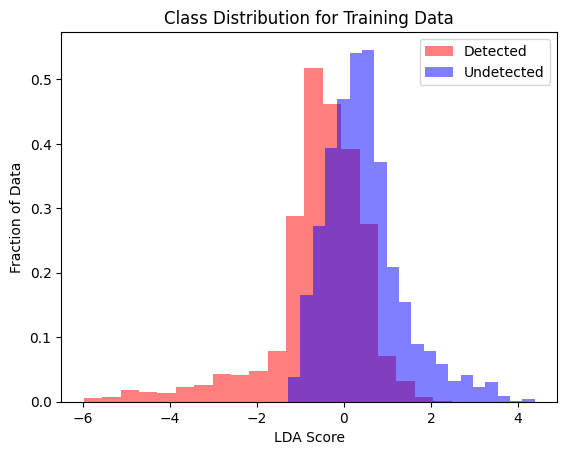

In [ ]:
## LDA Process Below

## Excluding the error class
binary_set = dataframe[dataframe['Class']!='Negative Flux Error']

## Separating Data from Classes
data = binary_set.iloc[:, :-1]
classes = binary_set.iloc[:,-1]


train_data, test_data, train_classes, test_classes = train_test_split(data, classes, test_size=0.5, train_size=0.5, stratify=classes)

## Training the LDA
lda = LDA()
lda.fit(train_data, train_classes)

## Testing LDA
pred_classes = lda.predict(test_data)

accuracy = accuracy_score(test_classes, pred_classes, normalize=True)   ## Computing accuracy of LDA prediction
print('Accuracy', accuracy)


train_scores = lda.decision_function(train_data)    ## Computing LDA score for the training set

scores_detected = train_scores[train_classes=='Detected']
scores_undetected = train_scores[train_classes=='Undetected']

plt.hist(scores_detected, bins=20, alpha=0.5, density=True, label='Detected', color='red')
plt.hist(scores_undetected, bins=20, alpha=0.5, density=True, label='Undetected', color='blue')
plt.legend()
plt.ylabel('Fraction of Data')
plt.xlabel('LDA Score')
plt.title('Class Distribution for Training Data')
plt.show()